Definition of the electrolyzer model and identification of the parameters for linear and piewcewise linear approximations

In [37]:
import numpy as np
import matplotlib.pyplot as plt


#------------------------------------------------------------------------------------------------
# ORIGINAL MODEL
#------------------------------------------------------------------------------------------------

# General constants and parameters
T0 = 20 + 273.15    # standard temperature [K]
p0 = 1.01325e5      # standard pressure [Pa]
R = 8.3145          # universal gas constant [J/(mol*K)]
F = 96485           # Faraday constant [C/mol]
z = 2               # number of electrons transferred in electrolysis reaction
Mm = 2.01568e-3     # molar mass of hydrogen [kg/mol]

# Electrolyzer parameters
p = 30e5            # operating pressure [Pa]
T = 70 + 273.15     # operating temperature [K]
R_io = 0.326        # internal stack resistance at standard conditions [Ohm]
k = 0.0395          # fitting parameter
dR_t = -3.812e-3    # temperature coefficient of resistance [Ohm/K]
e_rev0 = 1.476      # reversible voltage at standard conditions [V]
eta_F = 1           # Faraday efficiency

Pel_rtd = 10e6       # EL rated power [W]
Pel_min_ratio = 0.1                   # EL minimum power ratio [-]
Pel_min = Pel_min_ratio * Pel_rtd     # EL minimum power [W]
n_s = 275           # number of cells in series
n_p = 3700          # number of cells in parallel
n_tot = n_s * n_p   # total number of cells

# (Empirical) Electrical model
V_rev = e_rev0 + (R*T)/(2*F) * np.log(p/p0)         # reversible voltage [V]
Ri = R_io + k * np.log(p/p0) + dR_t * (T - T0)      

Pel_fit = np.linspace(Pel_min, Pel_rtd, 901)    # power array for fitting [W]
Pel_fit_cell = Pel_fit / n_tot                  # cell power array for fitting [W]

i_fit = (-V_rev + np.sqrt(V_rev**2 + 4*Ri*Pel_fit_cell)) / (2*Ri)      # current array [A]
H2_prod_fit = eta_F * Mm * 3600 * (n_tot * i_fit) / (z * F)            # H2 production rate array for fitting [kg/h]

In [38]:
#------------------------------------------------------------------------------------------------
# LINEAR MODEL
#------------------------------------------------------------------------------------------------

lin_param = np.polyfit(Pel_fit, H2_prod_fit, 1)      # fitting parameters of linear model
H2_prod_lin = lin_param[0] * Pel_fit + lin_param[1]  # H2 production rate linear model [kg/h]

abs_err = sum(abs(H2_prod_fit - H2_prod_lin))

# Alternative function for linear fitting
# lin_param = np.polynomial.polynomial.Polynomial.fit(Pel_fit, H2_prod_fit, 1)      # fitting parameters of linear model
# lin_param.convert().coef

# Print results
print(f"Slope: {lin_param[0]}, Intercept: {lin_param[1]}")
print(f"Absolute error: {abs_err}")

Slope: 1.3553366766353696e-05, Intercept: 16.76823668570389
Absolute error: 2226.1527903796064


In [39]:
#------------------------------------------------------------------------------------------------
# PIECEWISE LINEAR MODEL (2 segments)
#------------------------------------------------------------------------------------------------
H2_prod_reduce = H2_prod_fit[::10]
Pel_reduce = Pel_fit[::10]

# Search the optimal breakpoint for the piecewise linear approximation
n_break = 1    # number of breakpoints for the pwl model (x breakpoints => x+1 segments)

opt_slope_s1 = 0
opt_slope_s2 = 0
opt_intercept_s1 = 0
opt_intercept_s2 = 0
abs_err_best = np.inf
pwl_breakpoint = 0

for p1 in range(1, len(Pel_reduce) - n_break):
    slope_s1 = (H2_prod_reduce[p1] - H2_prod_reduce[0]) / (Pel_reduce[p1] - Pel_reduce[0])    # slope of the first segment
    intercept_s1 = H2_prod_reduce[0] - slope_s1 * Pel_reduce[0]
    slope_s2 = (H2_prod_reduce[-1] - H2_prod_reduce[p1]) / (Pel_reduce[-1] - Pel_reduce[p1])  # slope of the second segment
    intercept_s2 = H2_prod_reduce[p1] - slope_s2 * Pel_reduce[p1]

    abs_err = sum(abs(H2_prod_fit[0:p1*10] - (slope_s1 * Pel_fit[0:p1*10] + intercept_s1))) + \
          sum(abs(H2_prod_fit[p1*10:] - (slope_s2 * Pel_fit[p1*10:] + intercept_s2)))
    # print(abs_err)
    if abs_err < abs_err_best:
        abs_err_best = abs_err
        opt_slope_s1 = slope_s1
        opt_slope_s2 = slope_s2
        opt_intercept_s1 = intercept_s1
        opt_intercept_s2 = intercept_s2
        pwl_breakpoint = p1*10
        # print(f"Last best breackpoint index = {pwl_breakpoint}")

# Print results
print(f"Best breakpoint index: {pwl_breakpoint}, with absolute error = {abs_err_best}")
print(f"It corresponds to the power value: {Pel_fit[pwl_breakpoint]} W")
print(f"Slopes and intecepts of the segments are: \
      \n First segment slope = {opt_slope_s1}, intercept = {opt_intercept_s1}) \
        \n Second segment slope = {opt_slope_s2}, intercept = {opt_intercept_s2}")

# H2 production according to the pwl model (for plotting)
H2_prod_pwl_s1 = opt_slope_s1 * Pel_fit[0:pwl_breakpoint] + opt_intercept_s1
H2_prod_pwl_s2 = opt_slope_s2 * Pel_fit[pwl_breakpoint:] + opt_intercept_s2
H2_prod_pwl = np.concatenate((H2_prod_pwl_s1, H2_prod_pwl_s2))

Best breakpoint index: 380, with absolute error = 1507.0458963508345
It corresponds to the power value: 4800000.0 W
Slopes and intecepts of the segments are:       
 First segment slope = 1.6484087058405695e-05, intercept = 5.855589992088628)         
 Second segment slope = 1.1908614127158715e-05, intercept = 27.817860062074132


In [40]:
#------------------------------------------------------------------------------------------------
# PIECEWISE LINEAR MODEL (3 segments)
#------------------------------------------------------------------------------------------------
H2_prod_reduce = H2_prod_fit[::10]
Pel_reduce = Pel_fit[::10]

# Search the optimal breakpoint for the piecewise linear approximation
n_break = 2    # number of breakpoints for the pwl model (x breakpoints = x+1 segments)

opt_slope_s1 = 0
opt_slope_s2 = 0
opt_slope_s3 = 0
opt_intercept_s1 = 0
opt_intercept_s2 = 0
opt_intercept_s3 = 0
abs_err_best = np.inf
pwl_breakpoint = 0

for p1 in range(1, len(Pel_reduce) - n_break):
    slope_s1 = (H2_prod_reduce[p1] - H2_prod_reduce[0]) / (Pel_reduce[p1] - Pel_reduce[0])    # slope of the first segment
    intercept_s1 = H2_prod_reduce[0] - slope_s1 * Pel_reduce[0]                               # intercept of the first segment
    for p2 in range(p1 + 1, len(Pel_reduce) - n_break + 1):
        slope_s2 = (H2_prod_reduce[p2] - H2_prod_reduce[p1]) / (Pel_reduce[p2] - Pel_reduce[p1])  # slope of the second segment
        intercept_s2 = H2_prod_reduce[p1] - slope_s2 * Pel_reduce[p1]
        slope_s3 = (H2_prod_reduce[-1] - H2_prod_reduce[p2]) / (Pel_reduce[-1] - Pel_reduce[p2])  # slope of the third segment
        intercept_s3 = H2_prod_reduce[p2] - slope_s3 * Pel_reduce[p2]
        
        abs_err = sum(abs(H2_prod_fit[0:p1*10] - (slope_s1 * Pel_fit[0:p1*10] + intercept_s1))) + \
          sum(abs(H2_prod_fit[p1*10:p2*10] - (slope_s2 * Pel_fit[p1*10:p2*10] + intercept_s2))) + \
          sum(abs(H2_prod_fit[p2*10:] - (slope_s3 * Pel_fit[p2*10:] + intercept_s3)))
        # print(abs_err)

        if abs_err < abs_err_best:
            abs_err_best = abs_err
            opt_slope_s1 = slope_s1
            opt_slope_s2 = slope_s2
            opt_slope_s3 = slope_s3
            opt_intercept_s1 = intercept_s1
            opt_intercept_s2 = intercept_s2
            opt_intercept_s3 = intercept_s3
            pwl_breakpoint_p1 = p1*10
            pwl_breakpoint_p2 = p2*10
            # print(f"Last best breackpoint indexes = {pwl_breakpoint_p1}, {pwl_breakpoint_p2}")

            
# Print results
print(f"Best breakpoint indexes: {pwl_breakpoint_p1}, {pwl_breakpoint_p2} \n Absolute error = {abs_err_best}")
print(f"They correspond to the power values: {Pel_fit[pwl_breakpoint_p1]} W and {Pel_fit[pwl_breakpoint_p2]} W")
print(f"Slopes and intecepts of the segments are are: \
      \n First segment slope = {opt_slope_s1}, intercept = {opt_intercept_s1}) \
      \n Second segment slope = {opt_slope_s2}, intercept = {opt_intercept_s2} \
      \n Third segment slope = {opt_slope_s3}, intercept = {opt_intercept_s3}")

# H2 production according to the pwl model (for plotting)
H2_prod_pwl_s1 = opt_slope_s1 * Pel_fit[0:pwl_breakpoint_p1] + opt_intercept_s1
H2_prod_pwl_s2 = opt_slope_s2 * Pel_fit[pwl_breakpoint_p1:pwl_breakpoint_p2] + opt_intercept_s2
H2_prod_pwl_s3 = opt_slope_s3 * Pel_fit[pwl_breakpoint_p2:] + opt_intercept_s3
H2_prod_pwl = np.concatenate((H2_prod_pwl_s1, H2_prod_pwl_s2, H2_prod_pwl_s3))

Best breakpoint indexes: 240, 540 
 Absolute error = 670.0486892908687
They correspond to the power values: 3400000.0 W and 6400000.0 W
Slopes and intecepts of the segments are are:       
 First segment slope = 1.759204641062788e-05, intercept = 4.747630639866443)       
 Second segment slope = 1.3795338574023143e-05, intercept = 17.656437284322557       
 Third segment slope = 1.1377054770997392e-05, intercept = 33.13345362368736


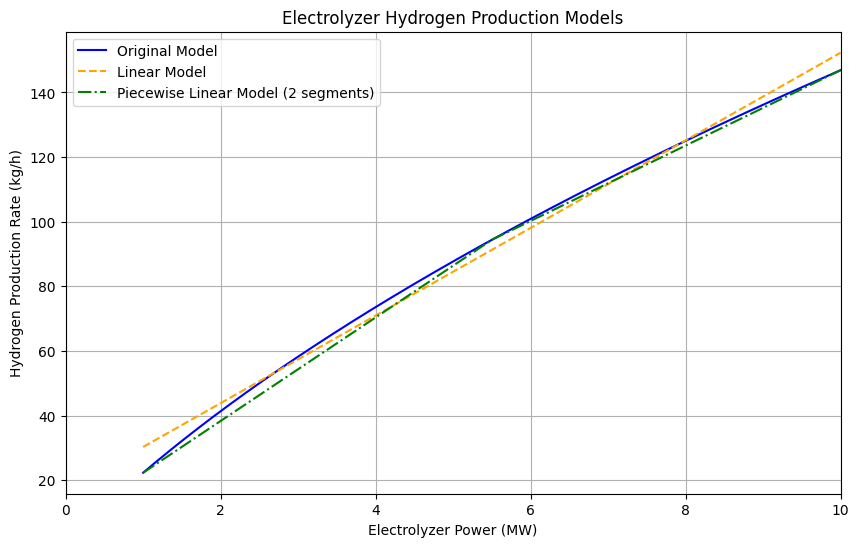

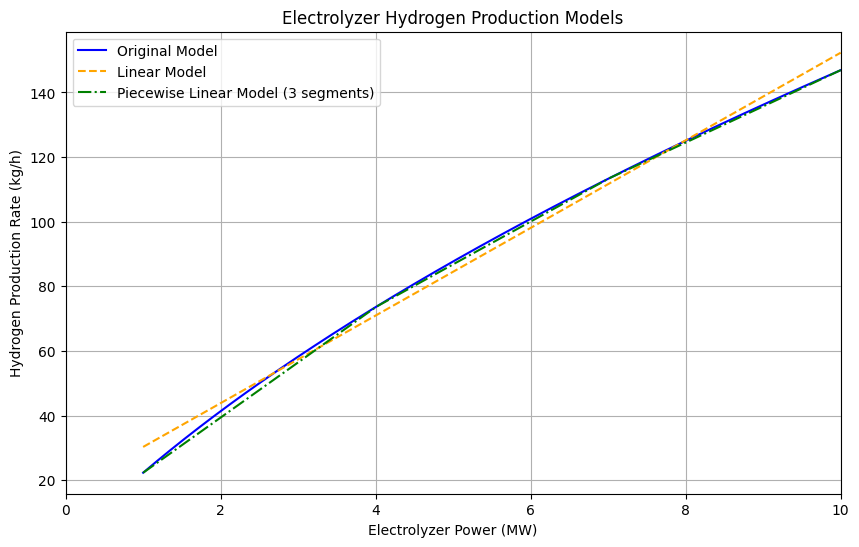

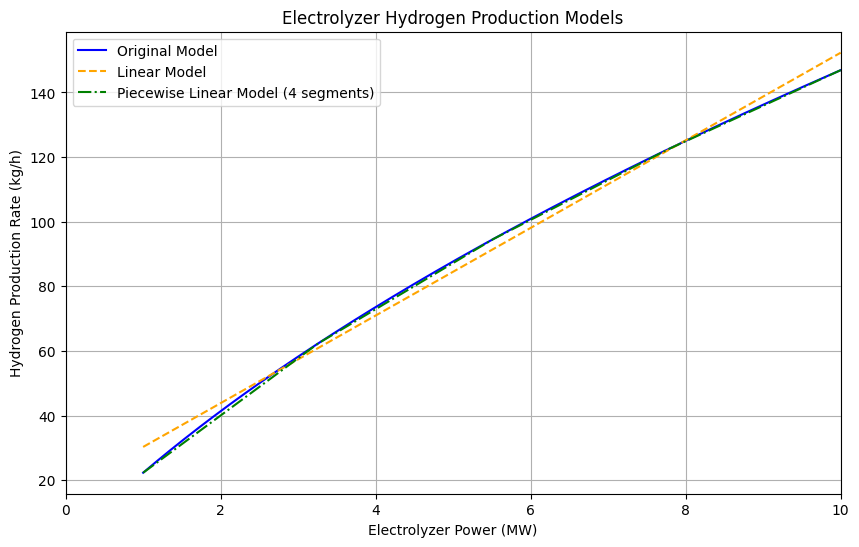

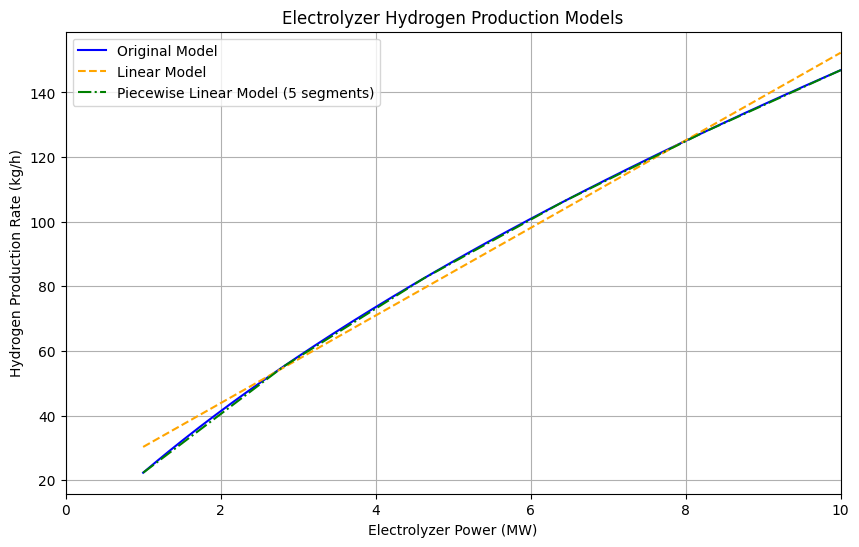

In [41]:
#------------------------------------------------------------------------------------------------
# PIECEWISE LINEAR MODEL (AI-generated, no breakpoint optimization)
#------------------------------------------------------------------------------------------------

for n_segments in [2, 3, 4, 5]:
    # Define breakpoints
    breakpoints = np.linspace(Pel_min, Pel_rtd, n_segments + 1)

    # Calculate H2 production at breakpoints
    H2_at_breakpoints = np.interp(breakpoints, Pel_fit, H2_prod_fit)

    # Piecewise linear model
    H2_prod_pwl_noopt = np.zeros_like(Pel_fit)
    for i in range(n_segments):
        mask = (Pel_fit >= breakpoints[i]) & (Pel_fit <= breakpoints[i + 1])
        slope = (H2_at_breakpoints[i + 1] - H2_at_breakpoints[i]) / (breakpoints[i + 1] - breakpoints[i])
        intercept = H2_at_breakpoints[i] - slope * breakpoints[i]
        H2_prod_pwl_noopt[mask] = slope * Pel_fit[mask] + intercept

    #------------------------------------------------------------------------------------------------
    # PLOTTING
    #------------------------------------------------------------------------------------------------

    plt.figure(figsize=(10, 6))
    plt.plot(Pel_fit / 1e6, H2_prod_fit, label='Original Model', color='blue')
    plt.plot(Pel_fit / 1e6, H2_prod_lin, label='Linear Model', linestyle='--', color='orange')
    plt.plot(Pel_fit / 1e6, H2_prod_pwl_noopt, label=f'Piecewise Linear Model ({n_segments} segments)', linestyle='-.', color='green')
    plt.xlabel('Electrolyzer Power (MW)')
    plt.ylabel('Hydrogen Production Rate (kg/h)')
    plt.title('Electrolyzer Hydrogen Production Models')
    plt.legend()
    plt.grid()
    plt.xlim(0, Pel_rtd / 1e6)
    # plt.ylim(0, np.max(H2_prod_fit) * 1.1)
    plt.show()


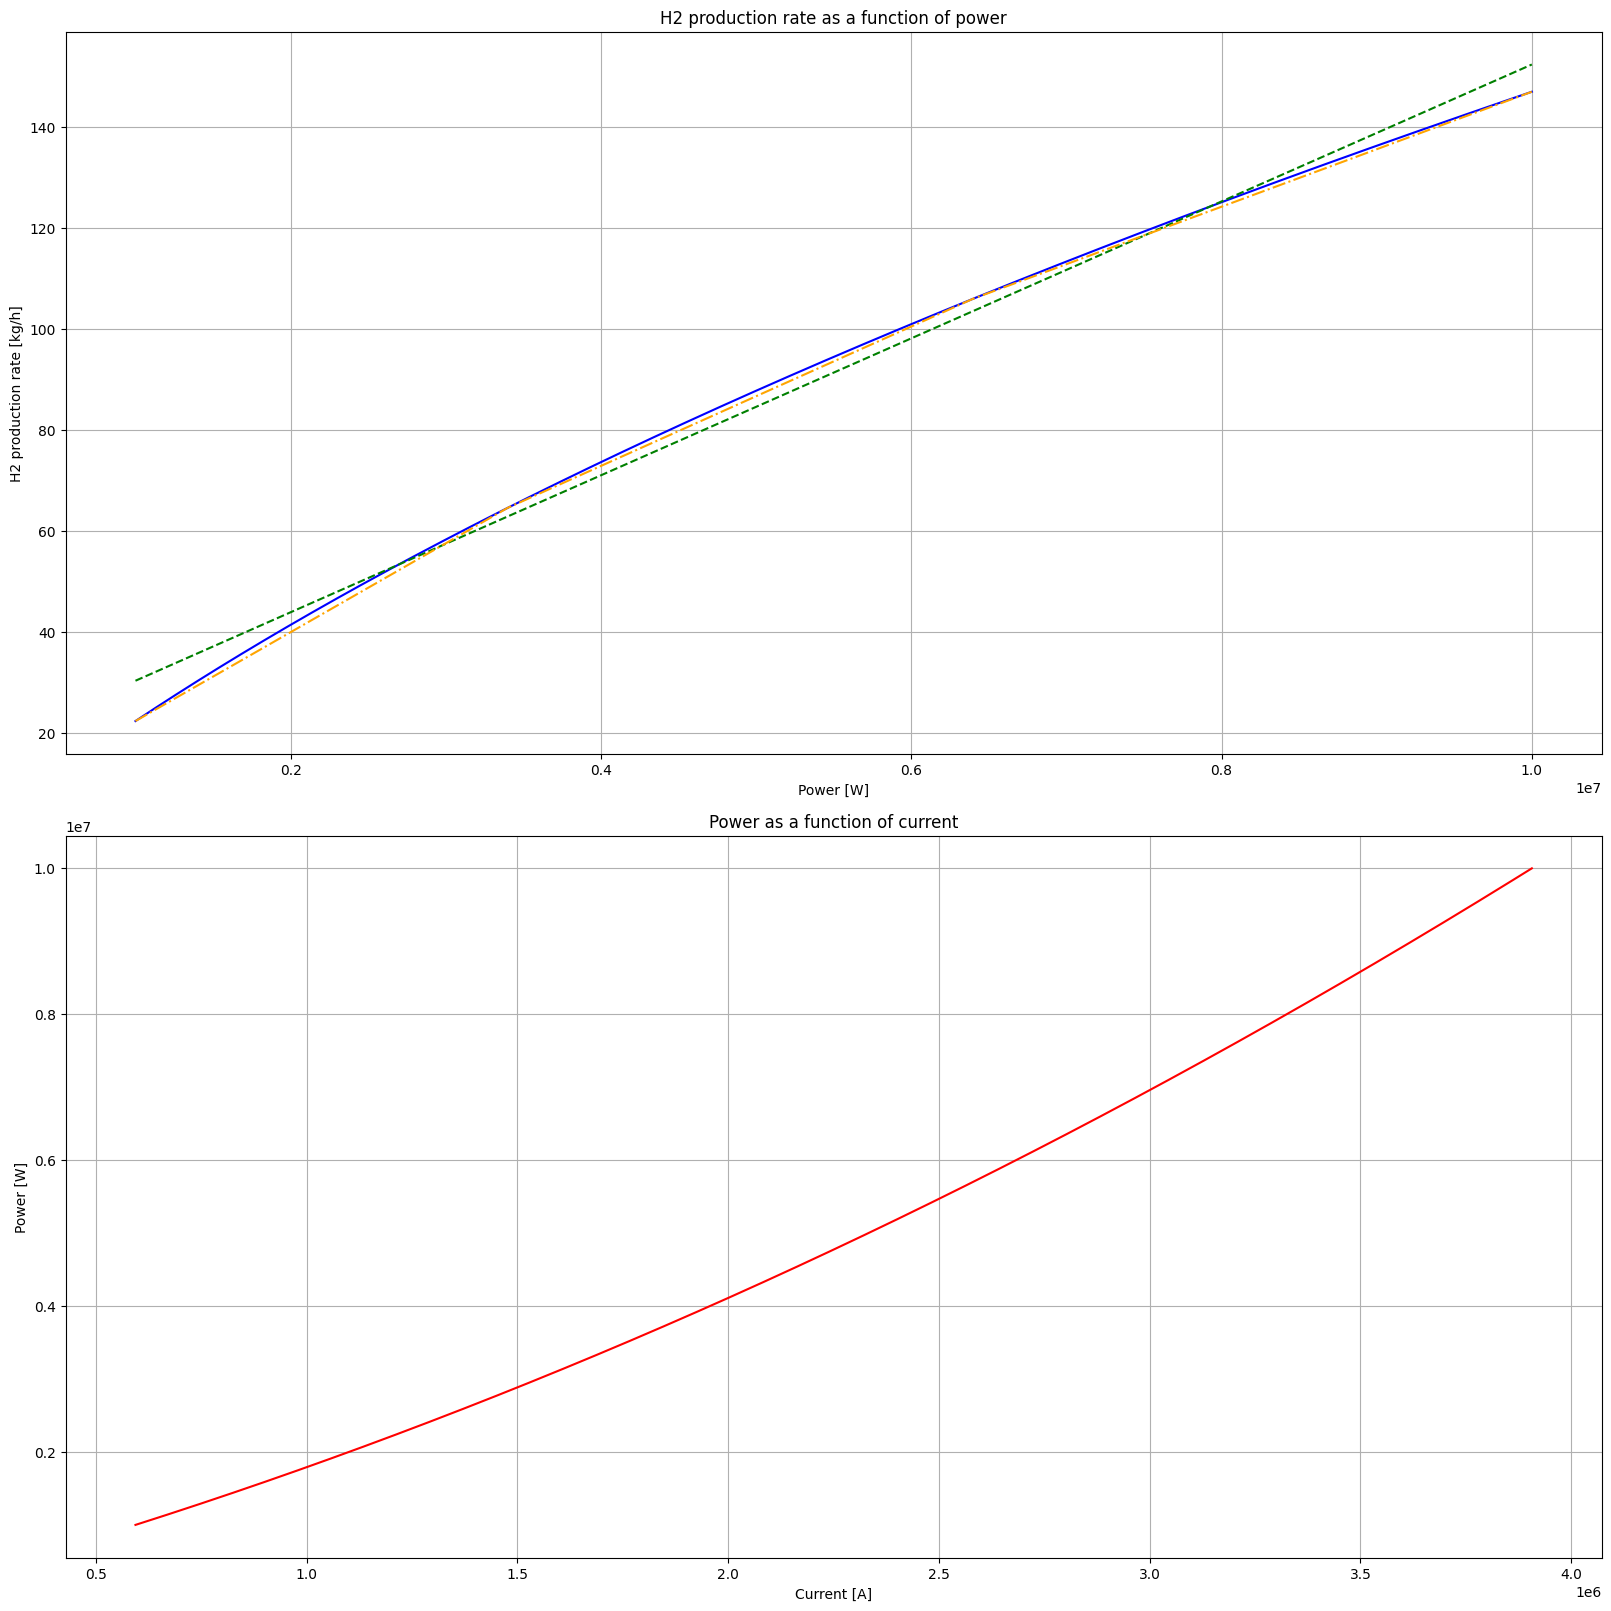

In [42]:
# Plotting (exact model, linear model and pwl model)
fig, axs = plt.subplots(2,1, figsize=(16, 16), layout='constrained')
axs[0].plot(Pel_fit, H2_prod_fit, color='blue')
axs[0].set_xlabel('Power [W]')
axs[0].set_ylabel('H2 production rate [kg/h]')
axs[0].set_title('H2 production rate as a function of power')
axs[0].plot(Pel_fit, H2_prod_lin, color='green', linestyle='--')
axs[0].plot(Pel_fit, H2_prod_pwl, color='orange', linestyle='-.')
# axs[0].axis([0.95e6, 1.02e6, 21.25, 22.5])
axs[0].grid(True)


axs[1].plot(i_fit * n_tot, Pel_fit, color='red')
axs[1].set_xlabel('Current [A]')
axs[1].set_ylabel('Power [W]')
axs[1].set_title('Power as a function of current')
# axs[1].axis([0, 650e3, 0, 1.1e6])
axs[1].grid(True)